# Исследование стартапов


## Введение

### Цели и задачи проекта

 - Подготовить качественный датасет для анализа данных о стартапах
 - Оценить достоверность данных и их пригодность для принятия бизнес-решений
 - Ответить на ключевые вопросы заказчика по предобработке данных и их бизнес значимости
 - Выявить факторы, влияющие на успешность сделок по покупке компаний

### Описание данных

 - Таблица 'acquisition' содержит информацию о покупках одними компаниями других компаний
 - Таблица 'company_and_rounds' cодержит информацию о компаниях и раундах финансирования
 - Таблица 'education' cодержит информацию об образовании сотрудника
 - Таблица 'people' cодержит информацию о сотрудникаx
 - Таблица 'degrees' cодержит информацию о типе образования сотрудника
 - Таблица 'fund' coдержит информацию о фондах
 - Таблица 'investment' cодержит информацию о раундах инвестирования


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* degrees.csv
* education.csv
* fund.csv
* investment.csv
* people.csv




In [187]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns


In [188]:
!pip install phik

In [189]:
# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


* Загружаем все данные по проекту

In [190]:
# Таким образом?
way =  'https://code.s3.yandex.net/datasets/'
car_df = pd.read_csv(way + 'company_and_rounds.csv')
acquisition_df = pd.read_csv(way + 'acquisition.csv')
people_df = pd.read_csv(way + 'people.csv')
education_df = pd.read_csv(way + 'education.csv')
degrees_df = pd.read_csv(way + 'degrees.csv')
fund_df = pd.read_csv(way + 'fund.csv')

###### Предобработка данных дадафрейма acquisition

In [191]:
# Выведем первые 5 строк датафрейма acquisition
acquisition_df.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [192]:
# Выводим информацию о датафрейме
acquisition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [193]:
# Подсчет количества строк в датафрейме
acquisition_df.shape

(9407, 6)

In [194]:
# Вывод количества дубликатов
acquisition_df.duplicated().sum()

np.int64(0)


В датафрейме 9407 строк, диапазон индексов — от 0 до 9406 и 6 столбцов. В данных 4 столбца типа int64 и 2 столбцa типа object. Датафрейм занимает 441,1 Kбайта памяти. В данных отсутствуют дубликаты.


###### Предобработка данных дадафрейма car_df

In [195]:
# Выведем первые 5 строк датафрейма car_df
car_df.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [196]:
# Выводим информацию о датафрейме
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217471 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

In [197]:
# Подсчет количества строк в датафрейме
car_df.shape

(217774, 22)

 - Выявим проблемы в данных, посмотрим аномально большие значения, аномально маленькие для учета в дальнейшей обработке данных

In [198]:
# Выведем статистику для числовых столбцов
car_df.describe()

,company ID,investment rounds,funding rounds,funding total,milestones,funding round id,company id,raised amount,pre money valuation,participants,is first round,is last round
count,217472.000000,217472.000000,217472.000000,2.174720e+05,217472.000000,52928.000000,52928.000000,5.292800e+04,5.292800e+04,52928.000000,52928.000000,52928.000000
mean,145287.383723,0.037711,0.612171,5.996191e+06,0.650442,28962.894536,98490.888433,7.946092e+06,3.294525e+05,1.528567,0.604576,0.604538
std,91998.156087,1.962712,1.433500,4.893160e+07,0.826408,16821.871803,88429.084864,4.216821e+07,6.531803e+07,2.060192,0.488946,0.488954
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,51960.750000,0.000000,0.000000,0.000000e+00,0.000000,14343.750000,26598.000000,2.463300e+05,0.000000e+00,0.000000,0.000000,0.000000
50%,165262.500000,0.000000,0.000000,0.000000e+00,0.000000,28885.500000,58080.000000,1.600000e+06,0.000000e+00,1.000000,1.000000,1.000000
75%,228199.250000,0.000000,0.000000,0.000000e+00,1.000000,43561.250000,171610.750000,6.700000e+06,0.000000e+00,2.000000,1.000000,1.000000
max,286215.000000,478.000000,15.000000,5.700000e+09,9.000000,57952.000000,286215.000000,3.835050e+09,1.500000e+10,36.000000,1.000000,1.000000


In [199]:
# Вывод количества дубликатов
car_df.duplicated().sum()

np.int64(0)


В датафрейме 217774 строк, диапазон индексов — от 0 до 217773 и 22 столбца. В данных 12 столбцов типа float64 и 10 столбцов типа object. Датафрейм занимает 36,6 Мбайта памяти. В данных отсутствуют дубликаты.
    
В датафрейме car_df лучше привести названия столбцов к единому стилю. Также нужно привести столбцы name и category code к единому стилю, чтобы проверить на дубликаты. Нужно выполнить замену столбцов founded_at, closed_at, funded_at на временной nullable тип, а столбцы company_id, investment_rounds, funding_rounds, participants, is_first_round, is_first_round, is_last_round к целочисленному типу.

###### Предобработка данных дадафрейма education

In [200]:
# Выведем первые 5 строк датафрейма education
education_df.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


In [201]:
# Подсчет количества строк в датафрейме
education_df.shape

(109610, 4)

In [202]:
# Выводим информацию о датафрейме
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [203]:
# Вывод количества дубликатов
education_df.duplicated().sum()

np.int64(0)


В датафрейме education_df 109610 строк, диапазон индексов — от 0 до 109609 и 4 столбца. В данных 2 столбца типа int64 и 2 столбцa типа object. Датафрейм занимает 3,3 Мбайта памяти. В данных отсутствуют дубликаты.
    
В education_df нужно поменять тип столбца graduated_at на временной nullable тип.

###### Предобработка данных дадафрейма people

In [204]:
# Выведем первые 5 строк датафрейма people
people_df.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [205]:
# Выводим информацию о датафрейме
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226700 non-null  object 
 2   last_name         226705 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [206]:
# Подсчет количества строк в датафрейме
people_df.shape

(226709, 5)

In [207]:
# Вывод количества дубликатов
people_df.duplicated().sum()

np.int64(0)


В датафрейме education_df 226709 строк, диапазон индексов — от 0 до 226708 и 5 столбцов. В данных 1 столбец типа int64, 3 столбцa типа object и 1 столбец типа float64. Датафрейм занимает 8,6 Мбайта памяти. В данных отсутствуют дубликаты.
    
В people_df приведем столбцы first_name и last_name к единому стилю.

###### Предобработка данных дадафрейма degrees

In [208]:
# Выведем первые 5 строк датафрейма people
degrees_df.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [209]:
# Выводим информацию о датафрейме
degrees_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98389 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [210]:
# Подсчет количества строк в датафрейме
degrees_df.shape

(109610, 4)

In [211]:
# Вывод количества дубликатов
degrees_df.duplicated().sum()

np.int64(0)

In [212]:
# Выведем уникальные значения degree_type
degrees_type = degrees_df['degree_type'].unique()
display(degrees_type)

array(['MBA', 'BA', 'MS', ..., 'Master of Public Health',
       "Master's of Music", 'bachelors'], dtype=object)


В датафрейме degrees_df 109610 строк, диапазон индексов — от 0 до 109609 и 4 столбца. В данных 1 столбец типа int64, 3 столбцa типа object. Датафрейм занимает 3,3 Мбайта памяти. В данных отсутствуют дубликаты.
    
Типы данных соответствуют. Приводить к единому стилю тут нет неоходимости.

### 1.2. Смена типов и анализ пропусков



In [213]:
dfs = {
    'Company Rounds': car_df,
    'Acquisition': acquisition_df,
    'People': people_df,
    'Education': education_df,
    'Degrees': degrees_df,
    'Fund': fund_df
}

def lookup_datasets(dfs, filenames=None):
    if filenames is None:
        filenames = [f"df_{i + 1}" for i in range(len(dfs))]

    for df, df_name in zip(dfs, filenames):
        print('-'*10,' '*5, df_name, ' '*5, '-'*10)

        # Пропущенные значения
        missing_data = df.isna().mean()
        missing_data_result = missing_data.apply(lambda x: f'{x:.2%}' if x > 0 else "")
        missing_data_name = "Пропущено" if missing_data.sum() > 0 else ""
        missing_data_result.name = missing_data_name

        # Типы данных
        dtypes_result = df.dtypes
        dtypes_result.name = "Тип данных колонки"
        fewest_nans_row = df.iloc[1:-1].isna().sum(axis=1).idxmin()

        values_type = df.loc[fewest_nans_row].map(type).T
        values_type.name = "Тип значения"

        # Объединяем результаты и пример данных
        result = pd.concat([
            dtypes_result, # типы
            values_type, # типы значений
            missing_data_result, # пропущенные значения
            df.iloc[0, :], # первая строка
            df.loc[fewest_nans_row].T, # полная строка
            df.iloc[-1, :] # последняя строка
        ], axis=1)

        display(result)

        # Проверка на полные дубликаты
        duplicates = df.duplicated().mean()
        if duplicates > 0:
            print(f'Полных дубликатов: {duplicates:.2%}')

        print()

# Проводим автоматический осмотр данных
column_counts = lookup_datasets(list(dfs.values()), list(dfs.keys()))

----------       Company Rounds       ----------


,Тип данных колонки,Тип значения,Пропущено,0,91,217773
company ID,float64,<class 'numpy.float64'>,0.14%,1.0,1006.0,NaN
name,object,<class 'str'>,0.14%,Wetpaint,Youlicit,NaN
category code,object,<class 'str'>,33.93%,web,web,NaN
status,object,<class 'str'>,0.14%,operating,closed,NaN
founded at,object,<class 'str'>,49.51%,2005-10-17,2006-09-01,NaN
closed at,object,<class 'str'>,98.42%,NaN,2010-05-22,NaN
domain,object,<class 'str'>,32.43%,wetpaint-inc.com,youlicit.com,NaN
network username,object,<class 'str'>,56.13%,BachelrWetpaint,youlicit,NaN
country code,object,<class 'str'>,50.13%,USA,USA,NaN
investment rounds,float64,<class 'numpy.float64'>,0.14%,0.0,0.0,NaN



----------       Acquisition       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,9406
id,int64,<class 'numpy.int64'>,,1,7,10529
acquiring_company_id,int64,<class 'numpy.int64'>,,11,59,53
acquired_company_id,int64,<class 'numpy.int64'>,,10,72,92846
term_code,object,<class 'str'>,80.54%,NaN,cash,NaN
price_amount,int64,<class 'numpy.int64'>,,20000000,60000000,42600000
acquired_at,object,<class 'str'>,0.31%,2007-05-30,2007-07-01,2013-12-12



----------       People       ----------


...

,Тип данных колонки,Тип значения,Пропущено,0,1,109609
id,int64,<class 'numpy.int64'>,,1,2,109610
person_id,int64,<class 'numpy.int64'>,,6117,6136,268528
instituition,object,<class 'str'>,0.05%,NaN,"Washington University, St. Louis",University of San Diego School of Law
graduated_at,object,<class 'str'>,47.04%,NaN,1990-01-01,NaN



----------       Degrees       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,109609
id,int64,<class 'numpy.int64'>,,1,2,109610
object_id,object,<class 'str'>,,p:6117,p:6136,p:268528
degree_type,object,<class 'str'>,10.24%,MBA,BA,J.D.
subject,object,<class 'str'>,25.83%,NaN,"English, French",NaN



----------       Fund       ----------


,Тип данных колонки,Тип значения,Пропущено,0,1,11651
id,int64,<class 'numpy.int64'>,,13131,1,2553
name,object,<class 'str'>,0.03%,NaN,Greylock Partners,fbFund
founded_at,object,<class 'str'>,60.48%,NaN,1965-01-01,NaN
domain,object,<class 'str'>,36.82%,NaN,greylock.com,developers.socialnet.com::fbfund.php
network_username,object,<class 'str'>,81.56%,NaN,greylockvc,fbFund
country_code,object,<class 'str'>,39.47%,NaN,USA,NaN
investment_rounds,int64,<class 'numpy.int64'>,,0,307,23
invested_companies,int64,<class 'numpy.int64'>,,0,196,21
milestones,int64,<class 'numpy.int64'>,,0,0,2


- Заменим типы столбцов acquisition_df

In [215]:
acquisition_df['acquired_at'] = acquisition_df['acquired_at'].astype('datetime64[ns]')


 - Заменен тип данных в столбце acquired_at
 - Пропуски содержатся только в двух столбцах, в столбце "варианты расчета" просто он может быть не указан, в столбце "дата сделки" тоже может просто отсутствовать такая информация



 - Приведем названия в датафрейме car_df к единому стилю

In [218]:
# Приведение названий столбцов к единому типу
car_df.columns = car_df.columns.str.split().str.join(' ').str.replace(' ', '_')
display (car_df.columns)

Index(['company_ID', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id', 'funded_at', 'funding_round_type',
       'raised_amount', 'pre_money_valuation', 'participants',
       'is_first_round', 'is_last_round'],
      dtype='object')

- Выполним нормализацию данных

In [219]:
# Приводим названия к нижнему регистру, заменяем пробел на нижнее подчеркивание
car_df['name'] = car_df['name'].str.lower().str.replace(' ', '_')
unique_names = car_df['name'].unique()
display(unique_names)


array(['wetpaint', 'flektor', 'there', ..., 'flowgram', 'pphotonet',
       'photonet'], dtype=object)

In [220]:
car_df['category_code'] = car_df['category_code'].str.lower().str.replace(' ', '_')
unique_category = car_df['category_code'].unique()
display(unique_category)


array(['web', 'games_video', 'network_hosting', 'advertising',
       'cleantech', nan, 'enterprise', 'other', 'consulting', 'mobile',
       'health', 'software', 'analytics', 'finance', 'education',
       'medical', 'manufacturing', 'biotech', 'ecommerce',
       'public_relations', 'hardware', 'search', 'news', 'government',
       'security', 'photo_video', 'travel', 'semiconductor', 'social',
       'legal', 'transportation', 'hospitality', 'sports', 'nonprofit',
       'fashion', 'messaging', 'music', 'automotive', 'design',
       'real_estate', 'local', 'nanotech', 'pets'], dtype=object)

In [270]:
# Вывод количества дубликатов
car_df.duplicated().sum()

np.int64(0)

- Заменим типы столбцов

In [222]:
car_df['company_id'] = car_df['company_id'].astype('Int64')
car_df['investment_rounds'] = car_df['investment_rounds'].astype('Int64')
car_df['funding_rounds'] = car_df['funding_rounds'].astype('Int64')
car_df['participants'] = car_df['participants'].astype('Int64')
car_df['is_first_round'] = car_df['is_first_round'].astype('Int64')
car_df['is_last_round'] = car_df['is_last_round'].astype('Int64')

In [223]:
car_df['founded_at'] = car_df['founded_at'].astype('datetime64[ns]')
car_df['closed_at'] = car_df['closed_at'].astype('datetime64[ns]')
car_df['funded_at'] = car_df['funded_at'].astype('datetime64[ns]')

In [224]:
# Выводим информацию о датафрейме
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_ID           217472 non-null  float64       
 1   name                 217471 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  Int64         
 10  funding_rounds       217472 non-null  Int64         
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

 - Столбцы приведены к единому стилю
 - Заменены типы данных в соответствующих столбцах
 - Пропуски не трогаем, так как может осуществлялось финансирование, только не указана компания.



- Заменим типы столбцов education_df

In [226]:
education_df['graduated_at'] = education_df['graduated_at'].astype('datetime64[ns]')


In [227]:
# Выводим информацию о датафрейме
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


 - Заменен тип данных в столбце graduated_at
 - Пропуски содержатся только в двух столбцах, в столбце  название учебного заведения и дата получения образования. Информация в них может просто отсутствовать, пропуски не трогаем.



- Приведем столбцы people_df к единому стилю

In [229]:
# Приводим 'first_name' к нижнему регистру, заменяем пробел на нижнее подчеркивание
people_df['first_name'] = people_df['first_name'].str.lower().str.replace(' ', '_')
unique_first = people_df['first_name'].unique()
display(unique_first)



array(['mark', 'peter', 'dr._steven', ..., 'ã\x89lie', 'tanis', 'dr._ray'],
      dtype=object)

In [230]:
# Приводим 'last_name' к нижнему регистру, заменяем пробел на нижнее подчеркивание
people_df['last_name'] = people_df['last_name'].str.lower().str.replace(' ', '_')
unique_last = people_df['last_name'].unique()
display(unique_last)



array(['zuckerberg', 'lester', 'e._saunders', ..., 'manda', 'gench',
       'tamberrino'], dtype=object)

In [231]:
# Вывод количества дубликатов
people_df.duplicated().sum()

np.int64(0)

 - Приведены данные в столбцах last_name и first_name к единому регистру, после приведения дубликаты также не найдены.
 - Пропуски содержатся только в четырех столбцах, видимо не все данные указали.



## Шаг 2. Предобработка данных, предварительное исследование

 - Составим сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:

  * типичный размер средств, выделяемый в рамках одного раунда;
  * общее количество раундов финансирования за этот год.

In [232]:
# Cоздадим столбец с годом из даты funded_at
car_df['year'] = car_df['funded_at'].dt.year
display(car_df)

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,888.0,1,2005-10-01,series-a,5250000.0,0.0,2,0,1,2005.0
1,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,889.0,1,2007-01-01,series-b,9500000.0,0.0,3,0,0,2007.0
2,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,2312.0,1,2008-05-19,series-c+,25000000.0,0.0,4,1,0,2008.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,...,NaN,<NA>,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,...,NaN,<NA>,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,...,56454.0,282847,2011-01-31,other,5500000.0,0.0,0,1,1,2011.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,...,56542.0,55477,2011-01-13,venture,10633300.0,0.0,0,0,1,2011.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,...,56543.0,55477,2012-05-31,venture,2125720.0,0.0,0,1,0,2012.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,...,56928.0,283492,2013-12-03,venture,3602480.0,0.0,5,1,1,2013.0


In [233]:
# Сгруппируем данные по годам, рассчитаем медиану значений raised_amount и общее количество раундов
pivot_table = (car_df.groupby('year').agg(median_raised_amount=('raised_amount', 'median'),
                                      round_count=('raised_amount', 'count')).reset_index())
display (pivot_table)

,year,median_raised_amount,round_count
0,1960.0,0.0,9
1,1973.0,0.0,1
2,1974.0,0.0,2
3,1984.0,41000.0,3
4,1985.0,0.0,1
5,1987.0,1250000.0,2
6,1989.0,15000.0,1
7,1990.0,1000000.0,1
8,1992.0,2000000.0,1
9,1993.0,62500.0,2


* Оставим в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.

In [234]:
# оставляем только годы с более чем 50 раундами
five_table = pivot_table[pivot_table['round_count'] > 50]
display(five_table)

,year,median_raised_amount,round_count
15,1999.0,2000000.0,76
16,2000.0,4200000.0,125
17,2001.0,3000000.0,96
18,2002.0,4200000.0,116
19,2003.0,3000000.0,159
20,2004.0,5000000.0,291
21,2005.0,5500000.0,1633
22,2006.0,5000000.0,2436
23,2007.0,3973320.0,3279
24,2008.0,3110000.0,3774


* Построим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

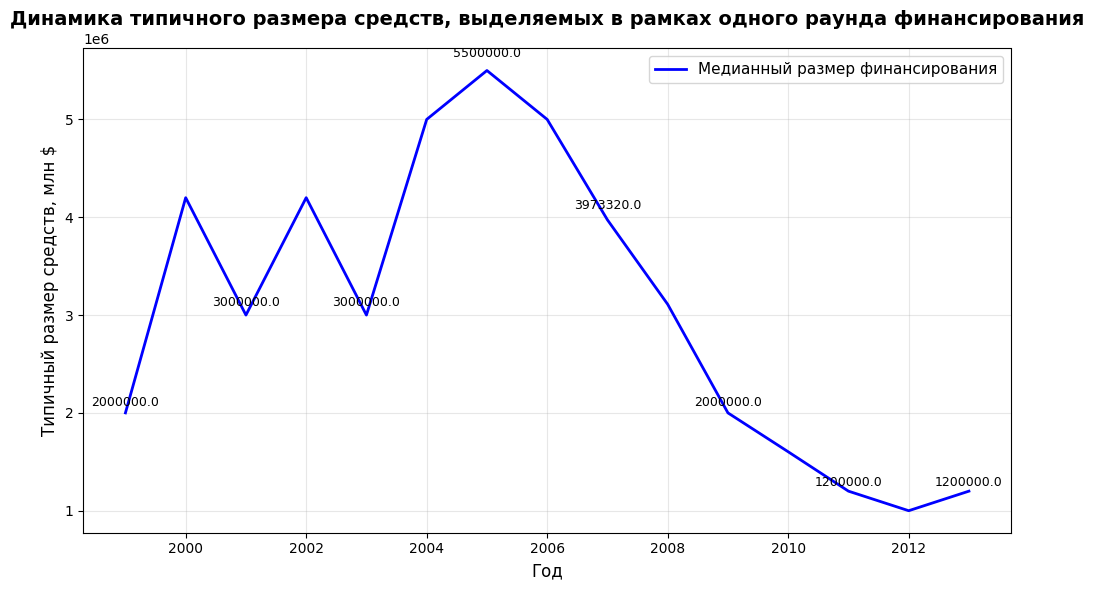

In [280]:
# Зададим размер графика
plt.figure(figsize=(10, 6))

# Построим диаграмму с синим цветом
plt.plot(five_table['year'],
         five_table['median_raised_amount'],
         color='blue',
         linewidth=2,
         label='Медианный размер финансирования')

# Зададим названия
plt.title('Динамика типичного размера средств, выделяемых в рамках одного раунда финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Типичный размер средств, млн $', fontsize=12)

# Добавим легенду
plt.legend(fontsize=11)


# Добавим подписи значений на графике (опционально)
for i, (year, value) in enumerate(zip(five_table['year'], five_table['median_raised_amount'])):
    if i % 2 == 0:  # Подписи только для каждого второго года для лучшей читаемости
        plt.text(year, value * 1.02, f'{value:.1f}',
                 ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2510514462.py:2: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  .groupby(pd.Grouper(key='funded_at', freq='AS'))\


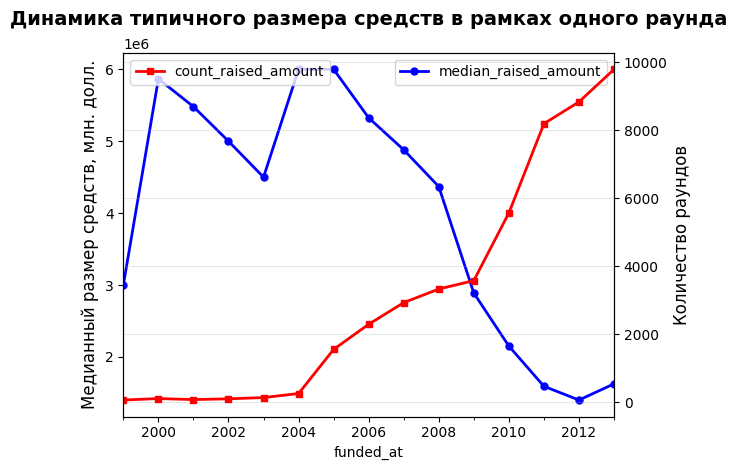

In [285]:
df_piv2 = car_df[car_df['raised_amount'] > 0]\
            .groupby(pd.Grouper(key='funded_at', freq='AS'))\
            .agg(
                median_raised_amount=('raised_amount', 'median'),
                count_raised_amount=('raised_amount', 'count')
            )
df_piv2 = df_piv2.query('count_raised_amount > 50').copy()

# Создаем график
ax = df_piv2[['median_raised_amount']].plot(color='blue', linewidth=2, marker='o', markersize=5)
ax2 = ax.twinx()
df_piv2[['count_raised_amount']].plot(ax=ax2, color='red', linewidth=2, marker='s', markersize=5)

# Настраиваем оси и заголовки
ax.set_ylabel('Медианный размер средств, млн. долл.', fontsize=12, color='black')
ax2.set_ylabel('Количество раундов', fontsize=12, color='black')

# Настройка цвета делений осей
ax.tick_params(axis='y', colors='black')
ax2.tick_params(axis='y', colors='black')

plt.xlabel('Год', fontsize=12, color='black')
plt.title('Динамика типичного размера средств в рамках одного раунда', fontsize=14, fontweight='bold', pad=20)



plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Типичный размер собранных в рамках одного раунда средств был максимален в 2005 со значением 5,5 млн долларов.
В 2013 году наблюдалось 11072 раундов с типичным финансированием 1,2 млн долларов, но произошел рост увеличения количества раундов финансирования.
     


### 2.2. Люди и их образование

Посмотрим, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

* Оценим насколько информация об образовании сотрудников полна. Разделим все компании на несколько групп по количеству сотрудников и оценим среднюю долю сотрудников без информации об образовании в каждой из групп.

In [237]:
# Объединение данных по идентификатору сотрудника
pe_df = pd.merge(people_df, education_df, on='id', how='left')
display(pe_df)


,id,first_name,last_name,company_id,network_username,person_id,instituition,graduated_at
0,10,mark,zuckerberg,5.0,NaN,6265.0,University of Pennsylvania,1989-01-01
1,100,peter,lester,27.0,NaN,938.0,Universidad Catolica del Uruguay,2006-01-01
2,1000,dr._steven,e._saunders,292.0,NaN,13098.0,Golden Gate University,1999-01-01
3,10000,neil,capel,2526.0,NaN,74038.0,Cairo University,NaT
4,100000,sue,pilsch,NaN,NaN,89666.0,Ohio State University,NaT
...,...,...,...,...,...,...,...,...
226704,99999,ramon,peypoch,NaN,NaN,257599.0,HTBLuVA Mödling,NaT
226705,174088,dr._ray,woods,188200.0,network,NaN,NaN,NaT
226706,118386,ricardo,durand,143419.0,itechsocialnet,NaN,NaN,NaT
226707,175827,mahesh,kumar,NaN,socialnethubs,NaN,NaN,NaT


In [238]:
# Отфильтруем сотрудников с образованием
pe_df['has_education'] = pe_df['instituition'].notnull()
# Группируем по company_id для подсчета количества сотрудников
company_size = (pe_df.groupby('company_id')['id'].nunique().reset_index(name='employee_count'))


Границы основаны на общепринятых категориях размеров компаний:
  - Маленькие компании : до 10 сотрудников. Маленькие компании обычно имеют ограниченное число сотрудников.
  - Средние компании : от 10 до 50 сотрудников. Средние компании — это организации среднего бизнеса.
  - Большие компании : более 50 сотрудников. Большие компании — крупные корпорации с большим штатом.

In [239]:
# Категоризация компаний по размеру
def categorize_company_size(size):
    if size == 1:
        return "one man"
    elif size < 5:
        return 'extra small'
    elif size < 10:
        return 'small'
    elif size < 50:
        return 'medium'
    elif size < 100:
        return 'Large'
    else:
        return 'extra large'
company_size['size_category'] = company_size['employee_count'].apply(categorize_company_size)

Объединяем данные о сотрудниках с информацией о размерах компаний и вычисляем долю сотрудников без образования для каждой группы.



In [240]:
# Присоединяем информацию о размере компании к основному датафрейму
merged_with_size = pd.merge(pe_df, company_size, on='company_id', how='left')

# Группируем по категории размера компании
grouped_data = (merged_with_size.groupby('size_category').agg(total_employees=('id', 'size'),
                no_education=('has_education', lambda x: sum(x == False))).reset_index())

# Вычисляем доли сотрудников без образования
grouped_data['no_education_dolia'] = grouped_data['no_education'] / grouped_data['total_employees']
display(grouped_data)

,size_category,total_employees,no_education,no_education_dolia
0,Large,359,180,0.501393
1,extra large,532,142,0.266917
2,extra small,9981,3529,0.353572
3,medium,2027,738,0.364085
4,one man,18117,9176,0.506486
5,small,3599,993,0.275910


Средняя доля сотрудников без информации об образовании для каждой группы:
 - Компании одного человека = 50 %
 - Очень маленькие компании = 35 %
 - Маленькие компании = 27 %
 - Средние компании = 36 %
 - Большие компании = 50 %
 - Очень большие = 27 %

Также можно присоединить таблицу degrees к таблицам people и education по ключу person.id = degrees.object_id, если цель анализа включает тип образования и специальности сотрудников.


### 2.3 Проблемный датасет
Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна. Хотя информация об общем объёме финансирования по раундам присутствует в других датасетах, заказчик считает данные `company_and_rounds.csv` о размере средств наиболее верными.


- Приведем данные в вид, который позволяет проводить анализ в разрезе отдельных компаний.

Разделим датасет company_and_rounds на два отдельных датасета. Данные содержат два столбца с РК 'company ID' и 'company_id'. Это наводит на мысль, что в данном датасете содержатся объединенные данные.

In [247]:
# Создание первого датасета fin_df
fin_df = car_df.loc[:, ['company_id',
                        'funded_at',
                        'funding_round_type',
                        'raised_amount',
                        'pre_money_valuation',
                        'participants',
                        'is_first_round',
                        'is_last_round']]

# Создание второго датасета com_df
com_df = car_df.loc[:, ['company_ID',
                            'name',
                            'category_code',
                            'status',
                            'founded_at',
                            'closed_at',
                            'domain',
                            'network_username',
                            'country_code',
                            'investment_rounds',
                            'funding_rounds',
                            'funding_total',
                            'milestones',
                            'funding_round_id']]
display(fin_df)
display(com_df)

,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,2005-10-01,series-a,5250000.0,0.0,2,0,1
1,1,2007-01-01,series-b,9500000.0,0.0,3,0,0
2,1,2008-05-19,series-c+,25000000.0,0.0,4,1,0
3,<NA>,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
4,<NA>,NaT,NaN,NaN,NaN,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...
217769,282847,2011-01-31,other,5500000.0,0.0,0,1,1
217770,55477,2011-01-13,venture,10633300.0,0.0,0,0,1
217771,55477,2012-05-31,venture,2125720.0,0.0,0,1,0
217772,283492,2013-12-03,venture,3602480.0,0.0,5,1,1


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,888.0
1,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,889.0
2,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,2312.0
3,10.0,flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,0,0.0,0.0,NaN
4,100.0,there,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,0,0.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,56454.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,56542.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,56543.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,56928.0


In [248]:
fin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           52928 non-null  Int64         
 1   funded_at            52680 non-null  datetime64[ns]
 2   funding_round_type   52928 non-null  object        
 3   raised_amount        52928 non-null  float64       
 4   pre_money_valuation  52928 non-null  float64       
 5   participants         52928 non-null  Int64         
 6   is_first_round       52928 non-null  Int64         
 7   is_last_round        52928 non-null  Int64         
dtypes: Int64(4), datetime64[ns](1), float64(2), object(1)
memory usage: 14.1+ MB


In [249]:
com_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_ID         217472 non-null  float64       
 1   name               217471 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  Int64         
 10  funding_rounds     217472 non-null  Int64         
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
 13  funding_round_id   52928 non-null   float64 

In [250]:
# Вывод количества пропусков в каждом столбце
missing_values= fin_df.isna().sum()
display(missing_values)

,0
company_id,164846
funded_at,165094
funding_round_type,164846
raised_amount,164846
pre_money_valuation,164846
participants,164846
is_first_round,164846
is_last_round,164846


In [251]:
# Удаление строк с пропущенными значениями в столбце 'company_id'
fin_df = fin_df.dropna(subset=['company_id'])
missing_values= fin_df.isna().sum()
display(missing_values)
fin_df.info()

,0
company_id,0
funded_at,248
funding_round_type,0
raised_amount,0
pre_money_valuation,0
participants,0
is_first_round,0
is_last_round,0


<class 'pandas.core.frame.DataFrame'>
Index: 52928 entries, 0 to 217773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           52928 non-null  Int64         
 1   funded_at            52680 non-null  datetime64[ns]
 2   funding_round_type   52928 non-null  object        
 3   raised_amount        52928 non-null  float64       
 4   pre_money_valuation  52928 non-null  float64       
 5   participants         52928 non-null  Int64         
 6   is_first_round       52928 non-null  Int64         
 7   is_last_round        52928 non-null  Int64         
dtypes: Int64(4), datetime64[ns](1), float64(2), object(1)
memory usage: 3.8+ MB


In [252]:
# Вывод количества пропусков в каждом столбце
missing_values= com_df.isna().sum()
display(missing_values)

,0
company_ID,302
name,303
category_code,73888
status,302
founded_at,107818
closed_at,214325
domain,70615
network_username,122240
country_code,109167
investment_rounds,302


In [253]:
# Удаление строк с пропущенными значениями в столбце 'company_id'
com_df = com_df.dropna(subset=['company_ID'])
missing_values= com_df.isna().sum()
display(missing_values)
com_df.info()

,0
company_ID,0
name,1
category_code,73586
status,0
founded_at,107516
closed_at,214023
domain,70313
network_username,121938
country_code,108865
investment_rounds,0


<class 'pandas.core.frame.DataFrame'>
Index: 217472 entries, 0 to 217471
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_ID         217472 non-null  float64       
 1   name               217471 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  Int64         
 10  funding_rounds     217472 non-null  Int64         
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
 13  funding_round_id   52626 non-null   float64      


## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных

В качестве основы для объединённой таблицы возьмем данные из обработанного датасета `company_and_rounds.csv` — выберем только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, и те, у которых в колонке `status` указано `acquired`.



In [254]:
# Проверяем количество строк до фильтрации
display(len(com_df))

217472

In [255]:
# Фильтруем компании, у которых funding_rounds или investment_rounds > 0 и status равен acquired
filtered_df = com_df[
                     (com_df['funding_rounds'] > 0) |
                     (com_df['investment_rounds'] > 0) &
                     (com_df['status'] == 'acquired')]

In [256]:
# Проверяем количество строк после фильтрации
display (len(filtered_df))

52711

In [257]:
# Проверяем аномальные значения по столбцам funding_rounds и investment_rounds
display(filtered_df[['funding_rounds', 'investment_rounds']].describe())

,funding_rounds,investment_rounds
count,52711.0,52711.0
mean,2.525659,0.0782
std,1.909263,3.877442
min,0.0,0.0
25%,1.0,0.0
50%,2.0,0.0
75%,3.0,0.0
max,15.0,478.0


 - 75% компаний проходят не более трех раундов финансирования.
 - Небольшое количество компаний проходит значительно больше раундов (до 15).
 - 75% компаний не получают инвестиционных раундов.
 - Очень подозрительное значения количества инвестиционных раундов (478).




### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

* По предобработанному столбцу `funding_total` графическим способом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.


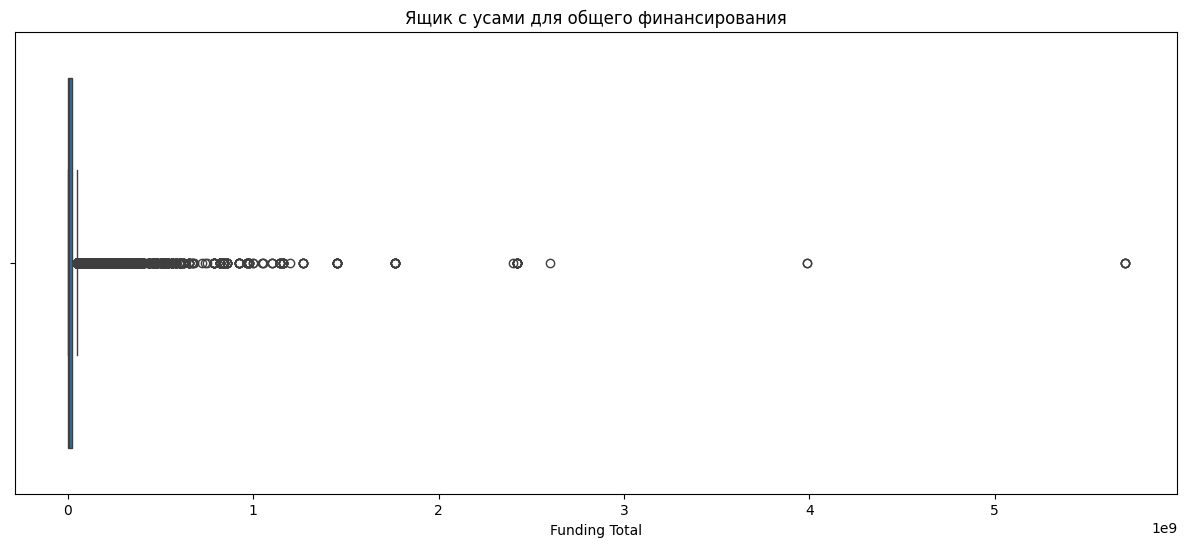

In [258]:
# Построим ящик с усами для выявления аномальных значений
plt.figure(figsize=(15, 6))
sns.boxplot(x=filtered_df['funding_total'])
plt.title('Ящик с усами для общего финансирования')
plt.xlabel('Funding Total')
plt.show()

Из ящика с усами видны очевидные выбросы, но сам ящик определить трудно. Поэтому построим гистограмму с логарифмической шкалой

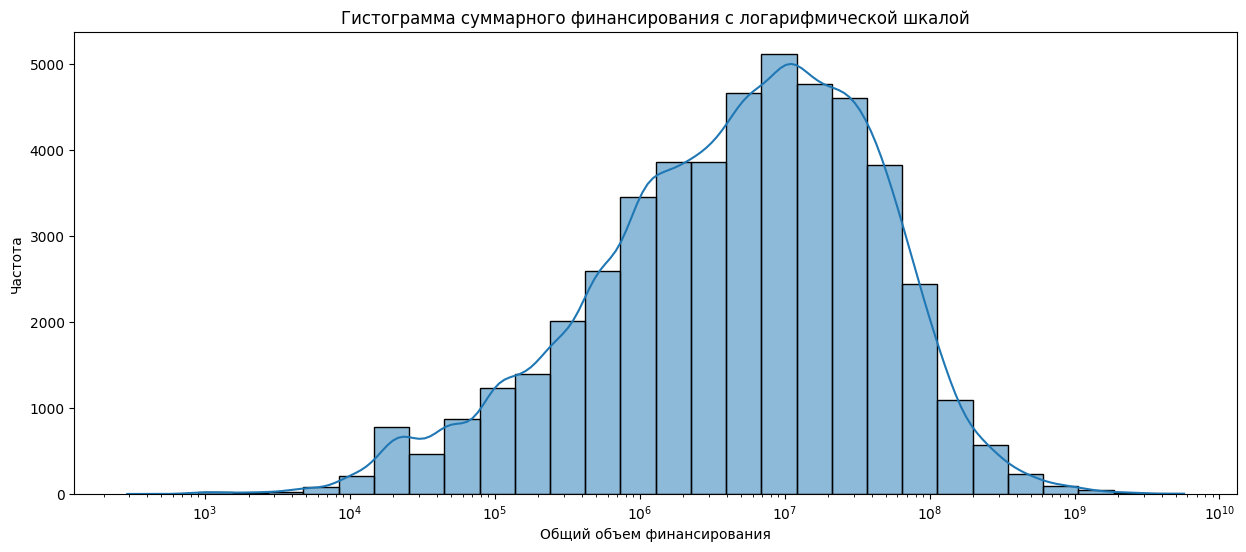

In [259]:
# Гистограмма с логарифмической шкалой
plt.figure(figsize=(15, 6))
sns.histplot(filtered_df['funding_total']
            [filtered_df['funding_total'] > 0],
            bins=30,
            kde=True,
            log_scale=True)
plt.title('Гистограмма суммарного финансирования с логарифмической шкалой')
plt.xlabel('Общий объем финансирования')
plt.ylabel('Частота')
plt.show()

In [260]:
# Проверяем аномальные значения 'funding_total'
display(filtered_df['funding_total'].describe())

,funding_total
count,5.271100e+04
mean,2.473874e+07
std,9.702958e+07
min,0.000000e+00
25%,6.000000e+05
50%,4.500000e+06
75%,2.050000e+07
max,5.700000e+09


- В среднем компании получают около 24.7 млн долларов финансирования.
- Очень высокое стандартное отклонение указывает на значительную дисперсию: большинство компаний получают относительно небольшие суммы, но есть исключения с огромными суммами.
- Есть компании, которые не получили никакого финансирования.
- У 25% компаний сумма финансирования составляет 600 тыс. долларов или меньше.
- Медиана равна 4.5 млн. долларов, что означает, что половина компаний получила 4.5 млню долларов или меньше.
- У 75% компаний сумма финансирования составляет 20.5 млн долларов или меньше.
- Максимальная сумма финансирования для одной компании составляет 5.7 млрд. долларов.

По ящику с усами особенно заметны выбросы максимальное значение 5.7 млрд долларов и еще несколько аномальных значений. Определим верхнюю границу выбросов.

In [261]:
iqr = filtered_df['funding_total'].quantile(0.75) - filtered_df['funding_total'].quantile(0.25)
upper = filtered_df['funding_total'].quantile(0.75) + 1.5*iqr
display(iqr)
display (f'Верхняя граница выбросов: {upper}')

np.float64(19900000.0)

'Верхняя граница выбросов: 50350000.0'


### 3.3. Исследуем компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.


In [262]:
# Объединение filtered_df и acquisition_df по acquiring_company_id и company_id
fil_ac_df = pd.merge(filtered_df, acquisition_df, left_on='company_ID', right_on='acquiring_company_id', how='left')

# Просмотр первых нескольких строк результата
display(fil_ac_df.head())

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,888.0,NaN,NaN,NaN,NaN,NaN,NaT
1,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,889.0,NaN,NaN,NaN,NaN,NaN,NaT
2,1.0,wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5.0,2312.0,NaN,NaN,NaN,NaN,NaN,NaT
3,1001.0,friendfeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,1,5000000.0,3.0,1644.0,NaN,NaN,NaN,NaN,NaN,NaT
4,10014.0,mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,1,0.0,4.0,6682.0,3727.0,10014.0,31658.0,NaN,0.0,2010-03-01


In [263]:
# Компании, которые были проданы за ноль или за один доллар и у них был ненулевой общий объём финансирования.
zero_or_one = fil_ac_df[(fil_ac_df['price_amount'].isin([0, 1])) & (fil_ac_df['funding_total'] > 0)]
display(zero_or_one)


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
29,100331.0,solectria_renewables,cleantech,operating,NaT,NaT,solren.com,SolectriaRen,USA,0,1,2.100000e+06,0.0,25194.0,6895.0,100331.0,152557.0,NaN,0.0,2012-03-20
51,100844.0,attunity,software,ipo,NaT,NaT,attunity.com,attunity,USA,0,4,1.050000e+07,1.0,25534.0,6113.0,100844.0,100840.0,NaN,0.0,2011-09-07
52,100844.0,attunity,software,ipo,NaT,NaT,attunity.com,attunity,USA,0,4,1.050000e+07,1.0,42773.0,6113.0,100844.0,100840.0,NaN,0.0,2011-09-07
53,100844.0,attunity,software,ipo,NaT,NaT,attunity.com,attunity,USA,0,4,1.050000e+07,1.0,42774.0,6113.0,100844.0,100840.0,NaN,0.0,2011-09-07
54,100844.0,attunity,software,ipo,NaT,NaT,attunity.com,attunity,USA,0,4,1.050000e+07,1.0,42775.0,6113.0,100844.0,100840.0,NaN,0.0,2011-09-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58225,12.0,network,social,ipo,2006-03-21,NaT,network.com,network,USA,0,8,1.160170e+09,6.0,25254.0,9286.0,12.0,1143.0,NaN,0.0,2013-08-13
58226,12.0,network,social,ipo,2006-03-21,NaT,network.com,network,USA,0,8,1.160170e+09,6.0,25254.0,9512.0,12.0,3614.0,NaN,0.0,2013-08-28
58248,43233.0,photonet,photo_video,acquired,2010-03-01,NaT,Photonet.com,Photonet,USA,0,3,5.750000e+07,3.0,12687.0,9380.0,43233.0,257714.0,NaN,0.0,2013-08-23
58249,43233.0,photonet,photo_video,acquired,2010-03-01,NaT,Photonet.com,Photonet,USA,0,3,5.750000e+07,3.0,21259.0,9380.0,43233.0,257714.0,NaN,0.0,2013-08-23


Количество таких компаний составляет 7450 шт.

 - Рассчитаем аналитически верхнюю и нижнюю границу выбросов для столбца funding_total и укажем, каким процентилям границы соответствуют.

In [264]:
# Получаем funding_total из отфильтрованных данных zero_or_one
funding_total_one= zero_or_one['funding_total']

In [265]:
# Рассчет границ выбросов
iqr = funding_total_one.quantile(0.75) - funding_total_one.quantile(0.25)

lower_bound = funding_total_one.quantile(0.25) - 1.5 * iqr
upper_bound = funding_total_one.quantile(0.75) + 1.5 * iqr

# Вывод границ выбросов
display(f'Нижняя граница: {lower_bound}')
display(f'Верхняя граница: {upper_bound}')

# Найдем соответствующие процентиль значения
lower_percentile = funding_total_one.quantile(0.25)
upper_percentile = funding_total_one.quantile(0.75)

display(f'Для нижней границы выбросов соответствует процентиль: {lower_percentile}')
display(f'Для верхней границы выбросов соответствует процентиль: {upper_percentile}')

'Нижняя граница: -256650000.0'

'Верхняя граница: 473350000.0'

'Для нижней границы выбросов соответствует процентиль: 17100000.0'

'Для верхней границы выбросов соответствует процентиль: 199600000.0'

 - В данном случае полученные границы (-256 млн и 473 млн) показывают значительный диапазон, причем нижняя граница отрицательна, что неправдоподобно для данных финансирования.  
 - Замена границ выбросов на значения, рассчитанные по процентилям, является более подходящим решением в данном случае.
Это позволяет исключить только самые редкие и экстремальные значения, сохранить большую часть данных для анализа, что особенно важно при работе с финансовыми показателями, где большие суммы могут быть правдивыми, но редкими событиями.


### 3.4. Цены стартапов по категориям

Категории стартапов с наибольшими ценами и значительным разбросом цен могут быть наиболее привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделим категории стартапов, характеризующиеся:

* наибольшими ценами;
* и наибольшим разбросом цен за стартап.


In [266]:
# Группировка данных по category_code и расчет средней цены
categories_by_mean_price = fil_ac_df.groupby('category_code')['price_amount'].mean().sort_values(ascending=False)
display(categories_by_mean_price.head(5))

,price_amount
category_code,
semiconductor,2.592514e+08
mobile,2.067033e+08
search,1.586317e+08
transportation,1.282683e+08
biotech,1.236852e+08


In [267]:
# Группировка данных по category_code и расчет разброса цен
price_std_by_category = fil_ac_df.groupby('category_code')['price_amount'].std().sort_values(ascending=False)
display(price_std_by_category.head(5))

,price_amount
category_code,
mobile,2.399692e+09
semiconductor,1.005539e+09
search,9.957473e+08
biotech,8.677731e+08
network_hosting,5.572202e+08


- Топ-5 позволяет быстро понять, какие категории наиболее значимы с точки зрения медианной цены или стандартного отклонения.
- Стандартное отклонение помогает понять, насколько сильно цены в категории варьируются. Высокое стандартное отклонение указывает на наличие как очень дорогих, так и относительно дешевых стартапов в категории.



 - Категории semiconductor и mobile демонстрируют самые высокие медианные значения, что говорит о том, что стартапы в этих категориях обычно продаются за значительные суммы.
 - Категории search, transportation и biotech также имеют высокие медианные значения, но немного ниже, чем у лидеров.
 - Категория mobile имеет самое высокое стандартное отклонение (2.399692e+09), что указывает на большой разброс цен внутри этой категории. Это может быть связано с тем, что в категории mobile встречаются как очень дорогие, так и относительно недорогие стартапы.
 - Категории semiconductor, search и biotech также демонстрируют высокое стандартное отклонение, что указывает на значительное варьирование цен.



### 3.5. Сколько раундов продержится стартап перед покупкой

* Необходимо проанализировать столбец `funding_rounds`. Исследуем значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.

* Построим график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы.

In [268]:
# Группировка данных по status и расчет среднего количества раундов финансирования
average_funding_rounds_by_status = fil_ac_df.groupby('status')['funding_rounds'].mean().sort_values(ascending=False)
display(average_funding_rounds_by_status)

,funding_rounds
status,
ipo,5.208589
acquired,2.763764
operating,2.58955
closed,1.881928


/tmp/ipython-input-3203296671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_funding_rounds_by_status.index,


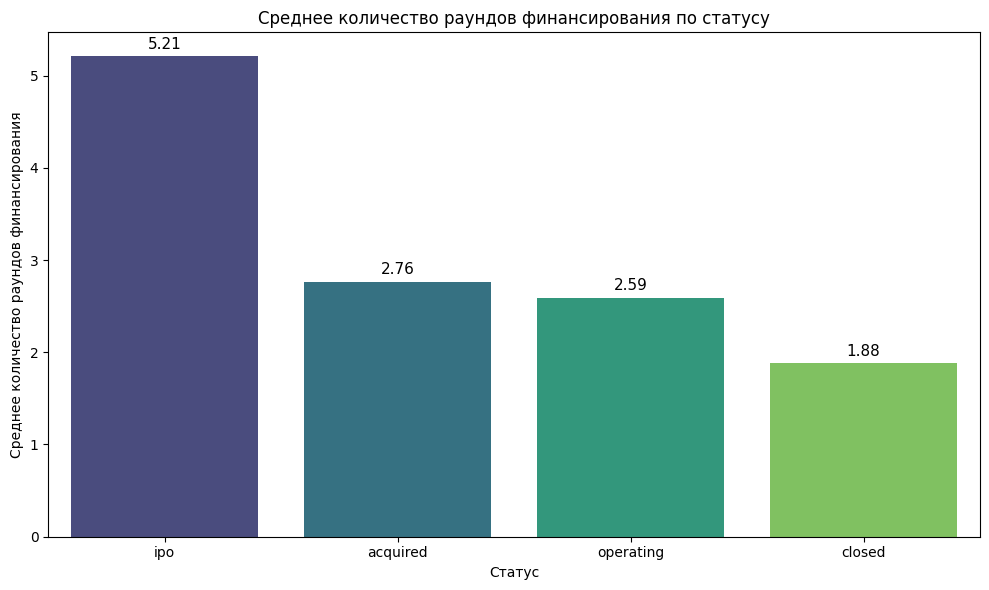

In [286]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_funding_rounds_by_status.index,
            y=average_funding_rounds_by_status.values,
            palette='viridis')

# Добавляем значения на столбцы
for i, value in enumerate(average_funding_rounds_by_status.values):
    plt.text(i, value + 0.05, f'{value:.2f}',
             ha='center', va='bottom', fontsize=11)

# Настройка графика
plt.title('Среднее количество раундов финансирования по статусу')
plt.xlabel('Статус')
plt.ylabel('Среднее количество раундов финансирования')
plt.xticks(rotation=0)
plt.tight_layout()

# Отображение графика
plt.show()

 - Стартапы IPO имеют самое большое количество раундов финансирования (в среднем 5.21). Это объясняется тем, что IPO требует значительных инвестиций на различных этапах развития компании.
 - Стартапы acquared в среднем проходят 2.76 раунда финансирования . Это меньше, чем у компаний c IPO, но все же значительно больше, чем у закрывшихся компаний.
 - Стартапы, которые продолжают работать (operating), в среднем проходят 2.59 раунда финансирования . Это близко к показателям компаний, которые были приобретены.
 - Стартапы, которые закрылись (closed), в среднем проходят только 1.88 раунда финансирования . Это наименьший показатель среди всех категорий.


## Шаг 4. Итоговый вывод и рекомендации


 - 75% компаний проходят не более трех раундов финансирования, что указывает на то, что большинство стартапов не требуют значительного количества инвестиций для достижения своих целей.
 - Небольшое количество компаний (до 15) проходит значительно больше раундов, что может свидетельствовать о высоком уровне интереса со стороны инвесторов или о необходимости в постоянном финансировании для роста.
 - В среднем компании получают около 24.7 млн долларов, однако высокое стандартное отклонение указывает на значительную дисперсию в суммах финансирования. Это означает, что большинство компаний получают относительно небольшие суммы, но есть и исключения с огромными суммами.
 - 25% компаний получают 600 тыс. долларов или меньше, что может указывать на высокие риски для инвесторов.
 - Медиана суммы финансирования составляет 4.5 млн долларов, что говорит о том, что половина компаний получает 4.5 млн долларов или меньше.
 - 75% компаний получают сумму финансирования 20.5 млн долларов или меньше, что также указывает на то, что большинство стартапов не достигают значительных объемов финансирования.
 - Стартапы в категориях semiconductor и mobile демонстрируют самые высокие медианные значения, что может указывать на их высокую добавленную стоимость и привлекательность для инвесторов.
 - Категории search, transportation и biotech также имеют высокие медианные значения, что делает их интересными для анализа.
 - Стартапы, достигшие статуса IPO, имеют наибольшее среднее количество раундов финансирования (5.21), что указывает на необходимость значительных инвестиций на различных этапах развития.
 - Стартапы, которые были приобретены, имеют меньшее среднее количество раундов (2.76), что может свидетельствовать о том, что они были куплены на более ранних стадиях.
 - Закрытые стартапы имеют наименьшее количество раундов (1.88), что может указывать на недостаток финансирования или неудачи в бизнесе.
